[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/optimization/05_constrained_optimization_lagrange/first_principles.ipynb)

# Module 05 — Constrained Optimization and Lagrange Multipliers

## 1. Why This Module Exists

Almost no optimization problem that describes something real is posed on all of $\mathbb{R}^n$. Budgets balance, probabilities sum to one, energy is conserved, a bead stays on its wire, a portfolio's weights add to the capital available. The decision variable is pinned to a curved surface, and the rule that carried [Module 02](../02_unconstrained_optimality_conditions/) — *stop where $\nabla f = \mathbf{0}$* — is then almost always vacuous: on a constraint surface the gradient of a generic objective never vanishes.

Imagine hiking on a mountainside whose altitude is $f(x, y)$ while required to stay exactly on a marked trail $h(x, y) = 0$. You want the lowest point *of the trail*, not of the mountain. At that point the terrain still slopes; what is true is that it slopes only *across* the trail, never along it. The whole of this module is the technical content of that sentence.

Turning it into arithmetic costs one new unknown per constraint. Introducing a multiplier $\lambda_j$ for each $h_j$ and forming the Lagrangian $\mathcal{L}(\mathbf{x}, \boldsymbol{\lambda}) = f(\mathbf{x}) + \boldsymbol{\lambda}^T \mathbf{h}(\mathbf{x})$ converts a *geometric* restriction on where you may look into an *algebraic* square system in $n + p$ unknowns. That trade — harder algebra, no geometry — is what makes constrained problems computable.

The multipliers are not bookkeeping. Each $\lambda_j^*$ measures the rate at which the optimal value moves when constraint $j$ is loosened: the shadow price of economics, the tension in a string, the inverse temperature of statistical mechanics. This module builds the theory (tangent spaces, LICQ, first- and second-order conditions, the bordered Hessian, sensitivity), proves it, and checks every formula numerically. [Module 06](../06_kkt_conditions_and_duality/) then repeats the story for inequalities.

## 2. Intuition

**Tangency.** Draw the contour lines $f(x, y) = c$ and lower $c$ until the contour is about to detach from the constraint set $h(x, y) = 0$. If a contour *crosses* the constraint curve transversally, you can slide along the constraint to a strictly lower contour, so a crossing point is never optimal. The optimum is the last value of $c$ whose contour still touches — and touching without crossing is tangency. Two curves are tangent exactly when their normals are parallel, so at the optimum $\nabla f(\mathbf{x}^*) \parallel \nabla h(\mathbf{x}^*)$.

**Decomposition.** The same fact said in components: split $\nabla f$ into a piece along the trail and a piece across it. Moving along the trail changes $f$ at the rate given by the first piece, so at a constrained optimum that piece must vanish. Nothing at all is required of the second piece, and generically it is large. "The gradient vanishes" is replaced by "the *tangential* gradient vanishes".

**Exchange rate.** Write the constraint as $h(\mathbf{x}) = b$ with an adjustable level $b$ — a budget, a total probability, an energy — and let $f^*(b)$ be the resulting optimal value. The multiplier turns out to be exactly the marginal price of that level, $d f^* / d b = -\lambda^*$. This is why the same symbol appears as a shadow price in economics, as a string tension in mechanics, and as $\beta = 1/(k_B T)$ in thermodynamics: all three are answers to "what does one more unit of the constraint buy?"

Keep the triad in view — **geometry** (tangency), **algebra** (a square stationary system), **economics** (sensitivity). Sections 4 and 5 make each one precise.

**Setup.** The cell below fixes plotting defaults and creates the single random generator `rng` used everywhere in this notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

**Figure 2.1 — tangency versus crossing.** The cell draws contours of $f(x,y) = x + y$ against the circle $h(x,y) = x^2 + y^2 - 1 = 0$, marks the constrained minimizer, and draws $\nabla f$ and $\nabla h$ there and at a non-optimal feasible point. The visual claim to check: the two gradient arrows are parallel at the minimizer and are not parallel anywhere else.

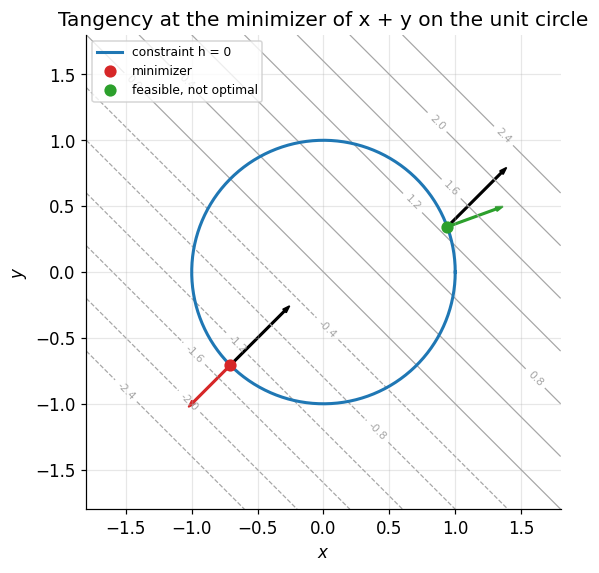

grad f            = [1. 1.]
grad h at min     = [-1.4142 -1.4142]
cross product at minimizer: 0.0
cross product at the other point: -1.1929498107838552


In [2]:
theta = np.linspace(0, 2 * np.pi, 400)
circ = np.stack([np.cos(theta), np.sin(theta)])

gx, gy = np.meshgrid(np.linspace(-1.8, 1.8, 300), np.linspace(-1.8, 1.8, 300))
fig, ax = plt.subplots(figsize=(5.6, 5.6))
cs = ax.contour(gx, gy, gx + gy, levels=np.linspace(-2.4, 2.4, 13),
                colors="0.65", linewidths=0.8)
ax.clabel(cs, fmt="%.1f", fontsize=7)
ax.plot(circ[0], circ[1], color="tab:blue", lw=2.0, label="constraint h = 0")

x_opt = np.array([-1, -1]) / np.sqrt(2)
x_off = np.array([np.cos(0.35), np.sin(0.35)])
for pt, col, lab in [(x_opt, "tab:red", "minimizer"), (x_off, "tab:green", "feasible, not optimal")]:
    ax.plot(*pt, "o", color=col, ms=7, label=lab)
    ax.arrow(*pt, 0.45, 0.45, color="k", width=0.012, length_includes_head=True)
    n = 0.45 * 2 * pt / np.linalg.norm(2 * pt)
    ax.arrow(*pt, *n, color=col, width=0.012, length_includes_head=True, linestyle="-")

ax.set_aspect("equal")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Tangency at the minimizer of x + y on the unit circle")
ax.legend(loc="upper left", fontsize=8)
plt.show()

print("grad f            =", np.array([1.0, 1.0]))
print("grad h at min     =", 2 * x_opt)
print("cross product at minimizer:", float(1.0 * 2 * x_opt[1] - 1.0 * 2 * x_opt[0]))
print("cross product at the other point:", float(1.0 * 2 * x_off[1] - 1.0 * 2 * x_off[0]))

The black arrow ($\nabla f$, constant) and the coloured arrow ($\nabla h$) are anti-parallel at the red point — their scalar cross product is $0$ to machine precision — and visibly misaligned at the green point, where the cross product is far from zero. At the green point the contour crosses the circle, so sliding along the circle strictly lowers $f$.

## 3. Definitions

### Definition 3.1 (Equality-constrained problem)

Let $f : \mathbb{R}^n \to \mathbb{R}$ and $h_j : \mathbb{R}^n \to \mathbb{R}$, $j = 1, \dots, p$, be continuously differentiable with $p \lt n$. The **equality-constrained problem** is

$$
\min_{\mathbf{x} \in \mathbb{R}^n} f(\mathbf{x}) \quad \text{subject to} \quad h_j(\mathbf{x}) = 0, \; j = 1, \dots, p,
$$

with **feasible set** $\mathcal{M} = \{\mathbf{x} \in \mathbb{R}^n : \mathbf{h}(\mathbf{x}) = \mathbf{0}\}$, where $\mathbf{h} = (h_1, \dots, h_p)^T$. A point $\mathbf{x}^* \in \mathcal{M}$ is a **local constrained minimizer** if some neighbourhood $U$ of $\mathbf{x}^*$ satisfies $f(\mathbf{x}^*) \le f(\mathbf{x})$ for all $\mathbf{x} \in \mathcal{M} \cap U$.

### Definition 3.2 (Regular point, LICQ)

A feasible point $\mathbf{x}$ is **regular**, equivalently the **Linear Independence Constraint Qualification (LICQ)** holds at $\mathbf{x}$, if the constraint gradients $\nabla h_1(\mathbf{x}), \dots, \nabla h_p(\mathbf{x})$ are linearly independent — that is, the Jacobian $D\mathbf{h}(\mathbf{x}) \in \mathbb{R}^{p \times n}$ has full row rank $p$.

### Definition 3.3 (Tangent space, linearized cone, tangent cone)

At $\mathbf{x} \in \mathcal{M}$ define three sets.

- The **tangent space** (linearized feasible directions)

$$
T(\mathbf{x}) = \{\mathbf{d} \in \mathbb{R}^n : \nabla h_j(\mathbf{x})^T \mathbf{d} = 0, \; j = 1, \dots, p\} = \ker D\mathbf{h}(\mathbf{x}).
$$

- The set of **feasible-curve velocities** $V(\mathbf{x}) = \{\dot{\mathbf{x}}(0)\}$ over all $C^1$ curves $\mathbf{x}(\cdot)$ with $\mathbf{x}(0) = \mathbf{x}$ and $\mathbf{x}(t) \in \mathcal{M}$ for $t$ near $0$.
- The **Bouligand tangent cone** $\mathcal{T}_B(\mathbf{x})$, the set of limits $\lim_k (\mathbf{x}_k - \mathbf{x}) / t_k$ over feasible sequences $\mathbf{x}_k \to \mathbf{x}$ in $\mathcal{M}$ and scalars $t_k \downarrow 0$.

Always $V(\mathbf{x}) \subseteq \mathcal{T}_B(\mathbf{x}) \subseteq T(\mathbf{x})$; Theorem 4.1 says LICQ collapses all three.

### Definition 3.4 (Lagrangian and multipliers)

The **Lagrangian** of Definition 3.1 is

$$
\mathcal{L}(\mathbf{x}, \boldsymbol{\lambda}) = f(\mathbf{x}) + \sum_{j=1}^p \lambda_j h_j(\mathbf{x}) = f(\mathbf{x}) + \boldsymbol{\lambda}^T \mathbf{h}(\mathbf{x}),
$$

where $\boldsymbol{\lambda} = (\lambda_1, \dots, \lambda_p)^T \in \mathbb{R}^p$ are the **Lagrange multipliers**, one per constraint. This sign convention — a **plus** sign, on a **minimization** problem — is used without exception throughout the module, including in every maximization problem, which is first converted to $\min (-f)$.

### Definition 3.5 (Bordered Hessian)

Write $W = \nabla^2_{\mathbf{xx}} \mathcal{L}(\mathbf{x}, \boldsymbol{\lambda})$ and $A = D\mathbf{h}(\mathbf{x})$. The **bordered Hessian** is the $(n+p) \times (n+p)$ symmetric matrix

$$
H_B(\mathbf{x}, \boldsymbol{\lambda}) =
\begin{bmatrix}
0 & A \\
A^T & W
\end{bmatrix},
$$

with a $p \times p$ zero block. For $p = 1$ the border is the single row $\nabla h(\mathbf{x})^T$ and its transpose.

## 4. Main Results

### Theorem 4.1 (Tangent space equals feasible-curve velocities)

*Hypotheses:* $\mathbf{h} \in C^1$; $\mathbf{x} \in \mathcal{M}$; LICQ holds at $\mathbf{x}$.

Then $V(\mathbf{x}) = \mathcal{T}_B(\mathbf{x}) = T(\mathbf{x}) = \ker D\mathbf{h}(\mathbf{x})$, a subspace of dimension $n - p$.

*Why each hypothesis is needed.* $C^1$ is what makes the chain rule and the implicit function theorem available at all. LICQ is what makes the linearization faithful: Problem L3.3 of [`exercises.ipynb`](exercises.ipynb) — the cusp $y^2 = x^3$ — has $\ker D\mathbf{h}(\mathbf{0}) = \mathbb{R}^2$ while $V(\mathbf{0}) = \{\mathbf{0}\}$ and $\mathcal{T}_B(\mathbf{0})$ is a single ray, so all three sets differ once LICQ is dropped.

### Theorem 4.2 (First-order necessary conditions — Lagrange)

*Hypotheses:* $f, \mathbf{h} \in C^1$; $\mathbf{x}^*$ is a local constrained minimizer of Definition 3.1; LICQ holds at $\mathbf{x}^*$.

Then there is a **unique** $\boldsymbol{\lambda}^* \in \mathbb{R}^p$ with

$$
\nabla_{\mathbf{x}} \mathcal{L}(\mathbf{x}^*, \boldsymbol{\lambda}^*) = \nabla f(\mathbf{x}^*) + \sum_{j=1}^p \lambda_j^* \nabla h_j(\mathbf{x}^*) = \mathbf{0}, \qquad \mathbf{h}(\mathbf{x}^*) = \mathbf{0}.
$$

*Why each hypothesis is needed.* Differentiability of $f$ is what lets a one-dimensional Fermat argument be run along a feasible curve. Local minimality (not merely stationarity of some other kind) is what forces that one-dimensional derivative to vanish. LICQ delivers, via Theorem 4.1, an actual feasible curve in every direction of $\ker D\mathbf{h}(\mathbf{x}^*)$ — without it the conclusion is false, as $\min x$ subject to $x^2 = 0$ shows: the minimizer is $x^* = 0$, $\nabla f(0) = 1$, $\nabla h(0) = 0$, and no $\lambda$ satisfies $1 + \lambda \cdot 0 = 0$. LICQ is also exactly what makes $\boldsymbol{\lambda}^*$ unique rather than merely existent.

### Theorem 4.3 (Second-order conditions)

*Hypotheses:* $f, \mathbf{h} \in C^2$; $\mathbf{x}^*$ feasible and regular; $(\mathbf{x}^*, \boldsymbol{\lambda}^*)$ satisfies Theorem 4.2. Write $W = \nabla^2_{\mathbf{xx}} \mathcal{L}(\mathbf{x}^*, \boldsymbol{\lambda}^*)$.

1. **(Necessity.)** If $\mathbf{x}^*$ is a local constrained minimizer, then $\mathbf{d}^T W \mathbf{d} \ge 0$ for every $\mathbf{d} \in T(\mathbf{x}^*)$.
2. **(Sufficiency.)** If $\mathbf{d}^T W \mathbf{d} \gt 0$ for every $\mathbf{d} \in T(\mathbf{x}^*) \setminus \{\mathbf{0}\}$, then $\mathbf{x}^*$ is a strict local constrained minimizer, with quadratic growth.

*Why each hypothesis is needed.* $C^2$ is needed because both parts are second-order Taylor arguments. Regularity again supplies feasible curves (necessity) and controls how far the manifold departs from its tangent plane (sufficiency). The restriction to $\mathbf{d} \in T(\mathbf{x}^*)$ cannot be dropped in either direction: $W$ is routinely indefinite on $\mathbb{R}^n$ at a genuine constrained minimum, and curvature in infeasible directions is unobservable.

For $p$ constraints, sufficiency can be certified by minor signs of $H_B$ of Definition 3.5: the last $n - p$ leading principal minors, of orders $2p+1, \dots, n+p$, must all have sign $(-1)^p$. For $n = 2, p = 1$ this reduces to $\det H_B \lt 0$ for a minimum and $\det H_B \gt 0$ for a maximum.

### Theorem 4.4 (Sensitivity / envelope theorem)

*Hypotheses:* $f, \mathbf{h} \in C^2$; for $\mathbf{b}$ near $\mathbf{b}_0$ the perturbed problem

$$
f^*(\mathbf{b}) = \min_{\mathbf{x}} f(\mathbf{x}) \quad \text{subject to} \quad h_j(\mathbf{x}) = b_j, \; j = 1, \dots, p,
$$

has a minimizer $\mathbf{x}^*(\mathbf{b})$ that is regular and satisfies the sufficient conditions of Theorem 4.3.

Then $\mathbf{x}^*(\cdot)$ and $\boldsymbol{\lambda}^*(\cdot)$ are $C^1$ near $\mathbf{b}_0$ and

$$
\frac{\partial f^*}{\partial b_j}(\mathbf{b}_0) = -\lambda_j^*(\mathbf{b}_0), \qquad j = 1, \dots, p.
$$

*Why each hypothesis is needed.* LICQ plus the strict second-order condition is precisely what makes the KKT matrix of the stationary system invertible, which is the hypothesis of the implicit function theorem that produces a differentiable $\mathbf{b} \mapsto (\mathbf{x}^*, \boldsymbol{\lambda}^*)$; without differentiability the left-hand side need not exist. $C^2$ is needed for that same Jacobian to be continuous.

### Theorem 4.5 (Rayleigh quotient as a constrained eigenproblem)

*Hypotheses:* $A \in \mathbb{R}^{n \times n}$ symmetric.

The stationary points of $\mathbf{x}^T A \mathbf{x}$ on $\{\mathbf{x}^T\mathbf{x} = 1\}$ are exactly the unit eigenvectors of $A$; the multiplier at each equals the corresponding eigenvalue up to sign fixed by Definition 3.4; and

$$
\max_{\mathbf{x}^T\mathbf{x} = 1} \mathbf{x}^T A \mathbf{x} = \lambda_{\max}(A), \qquad \min_{\mathbf{x}^T\mathbf{x} = 1} \mathbf{x}^T A \mathbf{x} = \lambda_{\min}(A).
$$

*Why the hypothesis is needed.* Symmetry gives $\nabla(\mathbf{x}^T A \mathbf{x}) = 2A\mathbf{x}$; for non-symmetric $A$ the gradient is $(A + A^T)\mathbf{x}$ and the stationary points are the eigenvectors of the symmetric part, not of $A$. Compactness of the sphere, which needs no hypothesis, is what guarantees the extrema are attained.

### Proposition 4.6 (Point-to-hyperplane distance)

*Hypotheses:* $\mathbf{a} \neq \mathbf{0}$, $H = \{\mathbf{x} : \mathbf{a}^T\mathbf{x} = b\}$.

Then $\operatorname{dist}(\mathbf{x}_0, H) = \lvert \mathbf{a}^T\mathbf{x}_0 - b \rvert / \lVert \mathbf{a} \rVert$, attained at the orthogonal projection. The hypothesis $\mathbf{a} \neq \mathbf{0}$ is both LICQ for this problem and what makes $H$ a hyperplane rather than $\emptyset$ or $\mathbb{R}^n$.

### Proposition 4.7 (Maximum entropy: uniform and Gibbs)

*Hypotheses:* $p_i \gt 0$ for all $i$; energies $E_1, \dots, E_n$ given; $\bar{E}$ strictly between $\min_i E_i$ and $\max_i E_i$.

Maximizing $S(\mathbf{p}) = -\sum_i p_i \ln p_i$ subject to $\sum_i p_i = 1$ gives $p_i = 1/n$ with $S = \ln n$; adding $\sum_i p_i E_i = \bar{E}$ gives $p_i = e^{-\beta E_i} / Z(\beta)$ with $Z(\beta) = \sum_k e^{-\beta E_k}$, and $\beta$ is the unique root of $-\,d \ln Z / d\beta = \bar{E}$. Interiority $p_i \gt 0$ is needed because $\ln p_i$ is undefined otherwise, and the strict interiority of $\bar{E}$ is exactly the condition making $\beta$ finite.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

**Step 1 ($V \subseteq T$, no regularity used).** Let $\mathbf{x}(t) \in \mathcal{M}$ for $t$ near $0$ with $\mathbf{x}(0) = \mathbf{x}$. Differentiating $\mathbf{h}(\mathbf{x}(t)) = \mathbf{0}$ at $t = 0$ by the chain rule gives $D\mathbf{h}(\mathbf{x})\dot{\mathbf{x}}(0) = \mathbf{0}$, so $\dot{\mathbf{x}}(0) \in \ker D\mathbf{h}(\mathbf{x}) = T(\mathbf{x})$.

**Step 2 ($\mathcal{T}_B \subseteq T$, no regularity used).** If $\mathbf{x}_k \in \mathcal{M}$, $\mathbf{x}_k \to \mathbf{x}$, $t_k \downarrow 0$ and $(\mathbf{x}_k - \mathbf{x})/t_k \to \mathbf{d}$, then a first-order Taylor expansion of each $h_j$ about $\mathbf{x}$ gives $0 = h_j(\mathbf{x}_k) = \nabla h_j(\mathbf{x})^T(\mathbf{x}_k - \mathbf{x}) + o(\lVert \mathbf{x}_k - \mathbf{x}\rVert)$. Dividing by $t_k$ and passing to the limit gives $\nabla h_j(\mathbf{x})^T\mathbf{d} = 0$.

**Step 3 ($T \subseteq V$, the direction that consumes LICQ).** Let $A = D\mathbf{h}(\mathbf{x})$ have full row rank $p$, so $AA^T \in \mathbb{R}^{p \times p}$ is invertible. Fix $\mathbf{d}$ with $A\mathbf{d} = \mathbf{0}$ and look for a feasible curve of the special form

$$
\mathbf{x}(t) = \mathbf{x} + t\mathbf{d} + A^T\mathbf{u}(t), \qquad \mathbf{u}(t) \in \mathbb{R}^p, \; \mathbf{u}(0) = \mathbf{0}.
$$

Define $F(t, \mathbf{u}) = \mathbf{h}(\mathbf{x} + t\mathbf{d} + A^T\mathbf{u})$. Then $F(0, \mathbf{0}) = \mathbf{0}$ and $D_{\mathbf{u}}F(0, \mathbf{0}) = A A^T$ is invertible, so the implicit function theorem produces a $C^1$ map $t \mapsto \mathbf{u}(t)$ with $\mathbf{u}(0) = \mathbf{0}$ and $F(t, \mathbf{u}(t)) = \mathbf{0}$ for all small $t$. The resulting curve lies in $\mathcal{M}$ by construction.

**Step 4 (its velocity is $\mathbf{d}$).** Differentiating $F(t, \mathbf{u}(t)) = \mathbf{0}$ at $t = 0$,

$$
A\mathbf{d} + AA^T\dot{\mathbf{u}}(0) = \mathbf{0} \quad \Longrightarrow \quad \dot{\mathbf{u}}(0) = -(AA^T)^{-1}A\mathbf{d} = \mathbf{0},
$$

because $A\mathbf{d} = \mathbf{0}$. Hence $\dot{\mathbf{x}}(0) = \mathbf{d} + A^T\dot{\mathbf{u}}(0) = \mathbf{d}$, so $\mathbf{d} \in V(\mathbf{x})$.

**Step 5 (collapse).** Steps 1–2 give $V \subseteq T$ and $\mathcal{T}_B \subseteq T$; Step 3 gives $T \subseteq V$; and $V \subseteq \mathcal{T}_B$ holds always, since a $C^1$ feasible curve supplies the sequence $\mathbf{x}_k = \mathbf{x}(t_k)$. The three sets coincide, and $\dim \ker A = n - p$ by rank-nullity.

$$
\boxed{V(\mathbf{x}) = \mathcal{T}_B(\mathbf{x}) = \ker D\mathbf{h}(\mathbf{x}), \qquad \dim = n - p \quad \text{under LICQ}}
$$

**Interpretation.** The linear-algebraic object $\ker D\mathbf{h}$, which anyone can compute from one Jacobian, is a faithful description of what motion the constraints actually permit. The consequence is that every statement about feasible motion may be replaced by a statement about a kernel — which is exactly what makes Theorem 4.2 a linear-algebra corollary rather than a differential-geometry theorem.

**Remark (what fails without LICQ).** Steps 1–2 never used regularity, so $V \subseteq \mathcal{T}_B \subseteq T$ is unconditional; only $T \subseteq V$ needs it, and it genuinely fails. For $h(x,y) = y^2 - x^3$ at the origin, $\nabla h(\mathbf{0}) = \mathbf{0}$ gives $T = \mathbb{R}^2$, while $V(\mathbf{0}) = \{\mathbf{0}\}$ and $\mathcal{T}_B(\mathbf{0}) = \{(d_1, 0) : d_1 \ge 0\}$. Weaker qualifications exist: the **Mangasarian–Fromovitz** condition (MFCQ) asks only that the equality gradients be independent and that some direction be tangent to them while strictly decreasing every active inequality — for pure equality constraints MFCQ and LICQ coincide — and **Abadie's** condition asks directly that $\mathcal{T}_B(\mathbf{x}) = T(\mathbf{x})$, the weakest hypothesis under which the proof of Theorem 4.2 still runs.

### Proof 5.2 (of Theorem 4.2)

**Step 1 (a feasible curve in every tangent direction).** Let $\mathbf{d} \in T(\mathbf{x}^*)$. By Theorem 4.1, proved in Proof 5.1 using LICQ, there is a $C^1$ curve $\mathbf{x}(t) \in \mathcal{M}$ with $\mathbf{x}(0) = \mathbf{x}^*$ and $\dot{\mathbf{x}}(0) = \mathbf{d}$.

**Step 2 (one-dimensional reduction).** Set $\phi(t) = f(\mathbf{x}(t))$. Every $\mathbf{x}(t)$ is feasible and $\mathbf{x}^*$ is a local constrained minimizer, so $\phi$ has a local minimum at the interior point $t = 0$ of its interval of definition. Fermat's theorem gives $\phi'(0) = 0$.

**Step 3 (chain rule).** $\phi'(0) = \nabla f(\mathbf{x}^*)^T\dot{\mathbf{x}}(0) = \nabla f(\mathbf{x}^*)^T\mathbf{d}$. Since $\mathbf{d} \in T(\mathbf{x}^*)$ was arbitrary, $\nabla f(\mathbf{x}^*) \in T(\mathbf{x}^*)^\perp$.

**Step 4 (identify the orthogonal complement).** With $A = D\mathbf{h}(\mathbf{x}^*)$, the fundamental theorem of linear algebra gives

$$
T(\mathbf{x}^*)^\perp = (\ker A)^\perp = \operatorname{range}(A^T) = \operatorname{span}\{\nabla h_1(\mathbf{x}^*), \dots, \nabla h_p(\mathbf{x}^*)\}.
$$

So $\nabla f(\mathbf{x}^*) = A^T\boldsymbol{\mu}$ for some $\boldsymbol{\mu} \in \mathbb{R}^p$, and $\boldsymbol{\lambda}^* = -\boldsymbol{\mu}$ gives the stated equation.

**Step 5 (uniqueness).** If $A^T\boldsymbol{\lambda} = A^T\tilde{\boldsymbol{\lambda}}$ then $A^T(\boldsymbol{\lambda} - \tilde{\boldsymbol{\lambda}}) = \mathbf{0}$; the columns of $A^T$ are the constraint gradients, linearly independent by LICQ, so $\boldsymbol{\lambda} = \tilde{\boldsymbol{\lambda}}$.

$$
\boxed{\nabla f(\mathbf{x}^*) + \sum_{j=1}^p \lambda_j^* \nabla h_j(\mathbf{x}^*) = \mathbf{0}, \qquad \boldsymbol{\lambda}^* \text{ unique under LICQ}}
$$

**Interpretation.** Optimality on a curved set is *tangential* stationarity, and the orthogonal complement of a kernel is a range, so "perpendicular to everything I may move along" becomes "a combination of the constraint gradients". The consequence is computational: the $n$ equations $\nabla_{\mathbf{x}}\mathcal{L} = \mathbf{0}$ together with the $p$ equations $\mathbf{h} = \mathbf{0}$ form a square system in $(\mathbf{x}, \boldsymbol{\lambda}) \in \mathbb{R}^{n+p}$, solvable by Newton's method.

### Proof 5.3 (of Theorem 4.3)

**Part 1 — necessity.** Let $\mathbf{d} \in T(\mathbf{x}^*)$ and, by Theorem 4.1, choose a $C^2$ feasible curve with $\mathbf{x}(0) = \mathbf{x}^*$, $\dot{\mathbf{x}}(0) = \mathbf{d}$; the construction of Proof 5.1 produces a $C^2$ curve whenever $\mathbf{h} \in C^2$, because the implicit function theorem returns a map as smooth as its data. Put $\psi(t) = \mathcal{L}(\mathbf{x}(t), \boldsymbol{\lambda}^*)$. On the curve $\mathbf{h} \equiv \mathbf{0}$, so $\psi(t) = f(\mathbf{x}(t))$, which has a local minimum at $t = 0$; hence $\psi''(0) \ge 0$. Differentiating twice and using $\nabla_{\mathbf{x}}\mathcal{L}(\mathbf{x}^*, \boldsymbol{\lambda}^*) = \mathbf{0}$,

$$
\psi''(0) = \dot{\mathbf{x}}(0)^T W \dot{\mathbf{x}}(0) + \nabla_{\mathbf{x}}\mathcal{L}(\mathbf{x}^*,\boldsymbol{\lambda}^*)^T\ddot{\mathbf{x}}(0) = \mathbf{d}^T W \mathbf{d}.
$$

The acceleration term drops out precisely because the Lagrangian, not $f$, is being differentiated — this is why $\nabla^2 f$ alone is the wrong test. Therefore $\mathbf{d}^T W \mathbf{d} \ge 0$ on $T(\mathbf{x}^*)$.

**Part 2 — sufficiency, Step 1 (set up a contradiction).** Suppose $\mathbf{x}^*$ is not a strict local constrained minimizer. Then there are feasible $\mathbf{x}_k \to \mathbf{x}^*$, $\mathbf{x}_k \neq \mathbf{x}^*$, with $f(\mathbf{x}_k) \le f(\mathbf{x}^*)$. Write $\mathbf{x}_k = \mathbf{x}^* + t_k\mathbf{d}_k$ with $t_k = \lVert \mathbf{x}_k - \mathbf{x}^*\rVert \to 0$ and $\lVert \mathbf{d}_k\rVert = 1$; by compactness of the unit sphere, pass to a subsequence with $\mathbf{d}_k \to \mathbf{d}$, $\lVert \mathbf{d}\rVert = 1$.

**Step 2 (the limit direction is tangent).** Taylor-expanding $h_j$ and using $h_j(\mathbf{x}_k) = h_j(\mathbf{x}^*) = 0$ gives $0 = t_k\nabla h_j(\mathbf{x}^*)^T\mathbf{d}_k + o(t_k)$; dividing by $t_k$ and letting $k \to \infty$ gives $\mathbf{d} \in T(\mathbf{x}^*)$.

**Step 3 (expand the Lagrangian, not $f$).** Feasibility gives $\mathcal{L}(\mathbf{x}_k, \boldsymbol{\lambda}^*) = f(\mathbf{x}_k)$ and $\mathcal{L}(\mathbf{x}^*, \boldsymbol{\lambda}^*) = f(\mathbf{x}^*)$. Since $\nabla_{\mathbf{x}}\mathcal{L}(\mathbf{x}^*, \boldsymbol{\lambda}^*) = \mathbf{0}$, a second-order Taylor expansion of $\mathcal{L}(\cdot, \boldsymbol{\lambda}^*)$ yields

$$
f(\mathbf{x}_k) = f(\mathbf{x}^*) + \tfrac{1}{2}t_k^2\,\mathbf{d}_k^T W \mathbf{d}_k + o(t_k^2).
$$

**Step 4 (contradiction).** From $f(\mathbf{x}_k) \le f(\mathbf{x}^*)$, dividing by $t_k^2 \gt 0$ and letting $k \to \infty$ gives $\mathbf{d}^T W \mathbf{d} \le 0$ with $\mathbf{d} \in T(\mathbf{x}^*)$, $\mathbf{d} \neq \mathbf{0}$ — contradicting the hypothesis.

**Step 5 (quadratic growth).** Let $\mu \gt 0$ be the smallest eigenvalue of $W$ restricted to $T(\mathbf{x}^*)$, attained on the compact unit sphere of that subspace. Repeating Steps 2–3 with the inequality kept, every feasible $\mathbf{x}$ close enough to $\mathbf{x}^*$ obeys $f(\mathbf{x}) \ge f(\mathbf{x}^*) + \tfrac{\mu}{4}\lVert \mathbf{x} - \mathbf{x}^*\rVert^2$.

$$
\boxed{\mathbf{d}^T W \mathbf{d} \ge 0 \ \text{on } T(\mathbf{x}^*) \ \text{(necessary)}; \qquad \mathbf{d}^T W \mathbf{d} \gt 0 \ \text{on } T(\mathbf{x}^*)\setminus\{\mathbf{0}\} \ \Rightarrow \ \text{strict local minimum}}
$$

**Interpretation.** Only the Hessian of the Lagrangian is meaningful, because the term $\sum_j \lambda_j \nabla^2 h_j$ is exactly the price the objective pays for the acceleration needed to stay feasible. The consequence is that a constrained minimum can sit where $\nabla^2 f$ is indefinite, or even negative definite along the tangent space, and the bordered Hessian is the determinant-level device that applies the correct test automatically.

### Proof 5.4 (of Theorem 4.4)

**Step 1 (differentiable dependence).** The stationary system $\nabla f(\mathbf{x}) + D\mathbf{h}(\mathbf{x})^T\boldsymbol{\lambda} = \mathbf{0}$, $\mathbf{h}(\mathbf{x}) = \mathbf{b}$ has Jacobian in $(\mathbf{x}, \boldsymbol{\lambda})$ equal to the bordered matrix of Definition 3.5, which is invertible under LICQ plus the strict second-order condition (see Section 7). The implicit function theorem therefore gives $C^1$ maps $\mathbf{b} \mapsto \mathbf{x}^*(\mathbf{b})$, $\mathbf{b} \mapsto \boldsymbol{\lambda}^*(\mathbf{b})$ satisfying both equations identically near $\mathbf{b}_0$.

**Step 2 (differentiate the value function).** With $f^*(\mathbf{b}) = f(\mathbf{x}^*(\mathbf{b}))$ the chain rule gives $\partial f^*/\partial b_j = \nabla f(\mathbf{x}^*)^T \partial \mathbf{x}^*/\partial b_j$.

**Step 3 (substitute stationarity).** Using $\nabla f(\mathbf{x}^*) = -\sum_k \lambda_k^*\nabla h_k(\mathbf{x}^*)$,

$$
\frac{\partial f^*}{\partial b_j} = -\sum_{k=1}^p \lambda_k^*\,\nabla h_k(\mathbf{x}^*)^T\frac{\partial \mathbf{x}^*}{\partial b_j}.
$$

**Step 4 (differentiate the constraints).** Differentiating $h_k(\mathbf{x}^*(\mathbf{b})) = b_k$ with respect to $b_j$ gives $\nabla h_k(\mathbf{x}^*)^T \partial \mathbf{x}^*/\partial b_j = \delta_{kj}$, the Kronecker delta.

**Step 5 (collapse the sum).** Substituting the delta leaves the single term $k = j$:

$$
\frac{\partial f^*}{\partial b_j} = -\sum_{k=1}^p \lambda_k^*\delta_{kj} = -\lambda_j^*.
$$

$$
\boxed{\dfrac{\partial f^*}{\partial b_j}(\mathbf{b}_0) = -\lambda_j^*(\mathbf{b}_0)}
$$

**Interpretation.** The multiplier is a derivative of the optimal value, so it carries units of objective per unit of constraint level and is a measurable quantity, not an artefact of the algebra. The consequence is that the entire first-order effect of moving a constraint is already known once the problem has been solved once — no re-solve is needed for a marginal analysis, which is why $\lambda^*$ is quoted as a price in economics, a tension in mechanics and an inverse temperature in thermodynamics.

### Proof 5.5 (of Theorem 4.5)

**Step 1 (cast in the convention of Definition 3.4).** Maximizing $\mathbf{x}^T A \mathbf{x}$ is minimizing $f(\mathbf{x}) = -\mathbf{x}^T A \mathbf{x}$, and the constraint is $h(\mathbf{x}) = \mathbf{x}^T\mathbf{x} - 1$. The Lagrangian carries a plus sign, as everywhere in this module:

$$
\mathcal{L}(\mathbf{x}, \lambda) = -\mathbf{x}^T A \mathbf{x} + \lambda(\mathbf{x}^T\mathbf{x} - 1).
$$

**Step 2 (stationarity is the eigenvalue equation).** Using $\nabla(\mathbf{x}^T A\mathbf{x}) = 2A\mathbf{x}$ for symmetric $A$,

$$
\nabla_{\mathbf{x}}\mathcal{L} = -2A\mathbf{x} + 2\lambda\mathbf{x} = \mathbf{0} \quad \Longrightarrow \quad A\mathbf{x} = \lambda\mathbf{x}.
$$

Every feasible point is regular, since $\nabla h = 2\mathbf{x} \neq \mathbf{0}$ on the sphere, so Theorem 4.2 misses no candidate.

**Step 3 (value at a stationary point).** If $A\mathbf{x} = \lambda\mathbf{x}$ with $\mathbf{x}^T\mathbf{x} = 1$ then $f(\mathbf{x}) = -\mathbf{x}^T(\lambda\mathbf{x}) = -\lambda$: the objective at each stationary point is minus its own multiplier.

**Step 4 (select the extremes).** The sphere is compact and $f$ continuous, so a minimizer of $f$ exists by Weierstrass and must be stationary, hence an eigenvector. Minimizing $-\lambda$ over the finitely many eigenvalues means maximizing $\lambda$, so $f^* = -\lambda_{\max}(A)$, i.e. $\max_{\mathbf{x}^T\mathbf{x}=1}\mathbf{x}^TA\mathbf{x} = \lambda_{\max}(A)$. Applying the same argument to $-f$ gives $\lambda_{\min}(A)$. By homogeneity $R(\mathbf{x}) = \mathbf{x}^TA\mathbf{x} / \mathbf{x}^T\mathbf{x}$ then has range $[\lambda_{\min}, \lambda_{\max}]$ on $\mathbf{x} \neq \mathbf{0}$.

**Step 5 (sensitivity, with no sign caveat).** Perturb the constraint to $\mathbf{x}^T\mathbf{x} = b$. Homogeneity gives $f^*(b) = -\lambda_{\max}(A)\,b$, so $\partial f^*/\partial b = -\lambda_{\max}(A) = -\lambda^*$, matching Theorem 4.4 verbatim — a check that is only available because the plus-sign convention of Definition 3.4 was used throughout.

$$
\boxed{A\mathbf{x}^* = \lambda^*\mathbf{x}^*, \qquad \max_{\mathbf{x}^T\mathbf{x}=1}\mathbf{x}^TA\mathbf{x} = \lambda_{\max}(A)}
$$

**Interpretation.** Eigenvectors are the stationary points of a quadratic form on the sphere and eigenvalues are its multipliers, so spectral theory is a special case of constrained optimization rather than a separate subject. The consequence is that PCA, spectral clustering, and the variational characterization of eigenvalues all inherit the sensitivity reading: an eigenvalue is the price of the normalization constraint.

### Proof 5.6 (of Proposition 4.6)

**Step 1 (formulate).** Minimize the smooth surrogate $f(\mathbf{x}) = \tfrac{1}{2}\lVert \mathbf{x} - \mathbf{x}_0\rVert^2$ subject to $h(\mathbf{x}) = \mathbf{a}^T\mathbf{x} - b = 0$; monotonicity of $t \mapsto \sqrt{2t}$ makes this equivalent to minimizing the distance itself.

**Step 2 (stationarity).** With $\mathcal{L} = \tfrac{1}{2}\lVert \mathbf{x} - \mathbf{x}_0\rVert^2 + \lambda(\mathbf{a}^T\mathbf{x} - b)$,

$$
\nabla_{\mathbf{x}}\mathcal{L} = (\mathbf{x} - \mathbf{x}_0) + \lambda\mathbf{a} = \mathbf{0} \quad \Longrightarrow \quad \mathbf{x}^* = \mathbf{x}_0 - \lambda\mathbf{a}.
$$

The correction to $\mathbf{x}_0$ is along the normal $\mathbf{a}$ and nowhere else — Proof 5.2 made concrete.

**Step 3 (solve for the multiplier).** Feasibility $\mathbf{a}^T\mathbf{x}^* = b$ gives $\mathbf{a}^T\mathbf{x}_0 - \lambda\lVert \mathbf{a}\rVert^2 = b$, hence $\lambda^* = (\mathbf{a}^T\mathbf{x}_0 - b) / \lVert \mathbf{a}\rVert^2$.

**Step 4 (distance).** $\lVert \mathbf{x}^* - \mathbf{x}_0\rVert = \lvert \lambda^*\rvert\,\lVert \mathbf{a}\rVert = \lvert \mathbf{a}^T\mathbf{x}_0 - b\rvert / \lVert \mathbf{a}\rVert$.

**Step 5 (second order).** $W = \nabla^2_{\mathbf{xx}}\mathcal{L} = I \succ 0$ on all of $\mathbb{R}^n$, so certainly on $T$; by Theorem 4.3 the point is a strict local minimizer, and by convexity of $f$ on the affine set $H$ it is the global one.

$$
\boxed{\operatorname{dist}(\mathbf{x}_0, H) = \dfrac{\lvert \mathbf{a}^T\mathbf{x}_0 - b\rvert}{\lVert \mathbf{a}\rVert}, \qquad \lambda^* = \dfrac{\mathbf{a}^T\mathbf{x}_0 - b}{\lVert \mathbf{a}\rVert^2}}
$$

**Interpretation.** The stationarity equation states the geometry before any algebra is done: move along the normal, and let the constraint fix how far. The consequence is the margin formula $2/\lVert \mathbf{w}\rVert$ of support vector machines, which is this proposition applied to two parallel hyperplanes.

### Proof 5.7 (of Proposition 4.7)

**Step 1 (normalization only).** Minimize $f(\mathbf{p}) = \sum_i p_i \ln p_i$ — the negative entropy, so the convention of Definition 3.4 applies unchanged — subject to $h(\mathbf{p}) = \sum_i p_i - 1 = 0$, with $\mathcal{L} = \sum_i p_i\ln p_i + \lambda(\sum_i p_i - 1)$.

**Step 2 (stationarity).** $\partial\mathcal{L}/\partial p_i = \ln p_i + 1 + \lambda = 0$ gives $p_i = e^{-1-\lambda}$, a value independent of $i$. Normalization forces $p_i = 1/n$, so $S = \ln n$.

**Step 3 (this stationary point is the global maximum of $S$).** $\nabla^2 f = \operatorname{diag}(1/p_i) \succ 0$ on the open simplex and the constraint is affine, so $f$ is strictly convex on the feasible set and its stationary point is the unique global minimizer of $f$, hence the unique global maximizer of $S$.

**Step 4 (add the energy constraint).** Impose also $\sum_i p_i E_i = \bar{E}$ with multiplier $\beta$:

$$
\mathcal{L} = \sum_i p_i \ln p_i + \lambda\Big(\sum_i p_i - 1\Big) + \beta\Big(\sum_i p_i E_i - \bar{E}\Big),
$$

whose stationarity $\ln p_i + 1 + \lambda + \beta E_i = 0$ gives $p_i \propto e^{-\beta E_i}$, and normalization fixes the constant:

$$
p_i = \frac{e^{-\beta E_i}}{Z(\beta)}, \qquad Z(\beta) = \sum_{k=1}^n e^{-\beta E_k}.
$$

**Step 5 (the second multiplier is pinned by $\bar{E}$).** Substituting into the energy constraint gives $-\,d\ln Z/d\beta = \bar{E}$. Since $d^2 \ln Z / d\beta^2 = \operatorname{Var}_{\mathbf{p}}(E) \gt 0$ whenever the $E_i$ are not all equal, $\beta \mapsto -d\ln Z/d\beta$ is strictly decreasing from $\max_i E_i$ to $\min_i E_i$, so a unique finite root $\beta$ exists for every $\bar{E}$ strictly inside that range. By Theorem 4.4 read on $S$, $\partial S^*/\partial\bar{E} = \beta$.

$$
\boxed{p_i = \frac{1}{n} \ \text{(normalization only)}, \qquad p_i = \frac{e^{-\beta E_i}}{Z(\beta)} \ \text{(with } \sum_i p_i E_i = \bar{E})}
$$

**Interpretation.** A linear constraint on an entropy maximization always produces an exponential tilt, with the multiplier as the tilt parameter. The consequence is that the whole exponential family — Boltzmann–Gibbs, Gaussian, softmax, logistic regression, conditional random fields — is one theorem applied to different constraint functions, and $\beta = 1/(k_BT)$ identifies temperature as a Lagrange multiplier.

## 6. Worked Examples

Every example below is computed by hand first, on the smallest object that still shows the mechanism, and then recomputed in code that asserts agreement.

### Example 6.1 (of Theorem 4.1) — a tangent space in $\mathbb{R}^3$

Constraints $h_1(\mathbf{x}) = x_1^2 + x_2^2 + x_3^2 - 1$ and $h_2(\mathbf{x}) = x_1 + x_2 + x_3 - 1$; the feasible set is the circle where a unit sphere meets a plane. At $\mathbf{x} = (1, 0, 0)^T$ both constraints hold.

$$
A = D\mathbf{h}(\mathbf{x}) = \begin{bmatrix} 2x_1 & 2x_2 & 2x_3 \\ 1 & 1 & 1 \end{bmatrix} = \begin{bmatrix} 2 & 0 & 0 \\ 1 & 1 & 1\end{bmatrix},
$$

which has rank $2$, so LICQ holds and $\dim T = 3 - 2 = 1$. Solving $A\mathbf{d} = \mathbf{0}$: the first row gives $d_1 = 0$, the second then gives $d_3 = -d_2$. Hence

$$
T(\mathbf{x}) = \operatorname{span}\{(0, 1, -1)^T\}, \qquad \mathbf{d} = \tfrac{1}{\sqrt{2}}(0, 1, -1)^T .
$$

Proof 5.1 predicts a feasible curve $\mathbf{x}(t) = \mathbf{x} + t\mathbf{d} + A^T\mathbf{u}(t)$ with $\dot{\mathbf{x}}(0) = \mathbf{d}$ exactly.

The cell builds that curve by solving $\mathbf{h}(\mathbf{x} + t\mathbf{d} + A^T\mathbf{u}) = \mathbf{0}$ for $\mathbf{u}$ with Newton's method, then checks two things: the curve stays feasible, and its central-difference velocity at $t = 0$ equals the hand-computed $\mathbf{d}$.

In [3]:
def h_ex1(x):
    return np.array([x @ x - 1.0, x.sum() - 1.0])


def Dh_ex1(x):
    return np.array([2.0 * x, np.ones(3)])


x_base = np.array([1.0, 0.0, 0.0])
A1 = Dh_ex1(x_base)
d_hand = np.array([0.0, 1.0, -1.0]) / np.sqrt(2.0)
print("A =\n", A1)
print("rank(A) =", np.linalg.matrix_rank(A1), " so dim T = 3 - 2 =", 3 - np.linalg.matrix_rank(A1))
print("A @ d_hand =", A1 @ d_hand)


def feasible_point(t):
    """Proof 5.1's curve: x(t) = x_base + t d + A^T u(t), with u solved by Newton."""
    u = np.zeros(2)
    for _ in range(50):
        x = x_base + t * d_hand + A1.T @ u
        F = h_ex1(x)
        if np.linalg.norm(F) < 1e-14:
            break
        u = u - np.linalg.solve(Dh_ex1(x) @ A1.T, F)
    return x_base + t * d_hand + A1.T @ u


t = 1e-5
vel = (feasible_point(t) - feasible_point(-t)) / (2 * t)
print("feasibility residual at t=0.05 :", np.linalg.norm(h_ex1(feasible_point(0.05))))
print("curve velocity at t=0          :", vel)
print("hand-computed d                :", d_hand)
assert np.linalg.norm(h_ex1(feasible_point(0.05))) < 1e-12
assert np.linalg.norm(vel - d_hand) < 1e-9

A =
 [[2. 0. 0.]
 [1. 1. 1.]]
rank(A) = 2  so dim T = 3 - 2 = 1
A @ d_hand = [0. 0.]
feasibility residual at t=0.05 : 2.220446049250313e-16
curve velocity at t=0          : [ 0.      0.7071 -0.7071]
hand-computed d                : [ 0.      0.7071 -0.7071]


The Newton correction keeps the curve on the intersection to residual $\sim 10^{-16}$, and its velocity reproduces the hand-computed tangent vector $(0, 1, -1)/\sqrt{2}$ to nine digits, exactly as Theorem 4.1 asserts.

### Example 6.2 (of Theorems 4.2 and 4.4) — the micro-example, by hand

Minimize $f(x, y) = x^2 + y^2$ subject to $x + y = b$.

1. **Lagrangian.** $\mathcal{L} = x^2 + y^2 + \lambda(x + y - b)$.
2. **Stationarity.** $2x + \lambda = 0$ and $2y + \lambda = 0$, so $x = y = -\lambda/2$.
3. **Feasibility.** $x + y = -\lambda = b$, hence $\lambda^*(b) = -b$ and $x^* = y^* = b/2$, giving $f^*(b) = b^2/2$.
4. **Curvature.** $W = \nabla^2_{\mathbf{xx}}\mathcal{L} = 2I \succ 0$, so Theorem 4.3 certifies a strict minimum.
5. **Sensitivity.** $df^*/db = b$, and $-\lambda^*(b) = b$. At $b = 1$: $\lambda^* = -1$, $x^* = y^* = 1/2$, $f^* = 1/2$, $df^*/db = 1$.

This five-step template — Lagrangian, stationarity, feasibility, curvature, sensitivity — is the routine to run on every problem in [`exercises.ipynb`](exercises.ipynb).

The cell recomputes $\lambda^*$, $\mathbf{x}^*$ and $f^*$ by solving the $3 \times 3$ stationary system numerically, and compares a central-difference slope of $f^*(b)$ against $-\lambda^*$ at $b = 1$.

In [4]:
K2 = np.array([[2.0, 0.0, 1.0],
               [0.0, 2.0, 1.0],
               [1.0, 1.0, 0.0]])          # [[2I, 1], [1^T, 0]]


def solve_micro(b):
    sol = np.linalg.solve(K2, np.array([0.0, 0.0, b]))
    x, y, lam = sol
    return np.array([x, y]), lam, x * x + y * y


xy1, lam1, f1 = solve_micro(1.0)
eps = 1e-6
f_plus = solve_micro(1.0 + eps)[2]
f_minus = solve_micro(1.0 - eps)[2]
slope = (f_plus - f_minus) / (2 * eps)

print(f"x* = {xy1},  lambda* = {lam1: .6f},  f* = {f1: .6f}")
print(f"df*/db  (central difference) = {slope: .8f}")
print(f"-lambda*                     = {-lam1: .8f}")
print(f"|difference| = {abs(slope + lam1): .3e}")
assert np.allclose(xy1, [0.5, 0.5]) and np.isclose(lam1, -1.0) and np.isclose(f1, 0.5)
assert abs(slope - (-lam1)) < 1e-7

x* = [0.5 0.5],  lambda* = -1.000000,  f* =  0.500000
df*/db  (central difference) =  1.00000000
-lambda*                     =  1.00000000
|difference| =  1.000e-12


The solver returns exactly the hand values $x^* = y^* = 1/2$, $\lambda^* = -1$, $f^* = 1/2$, and the measured slope of the value function agrees with $-\lambda^*$ to eight digits — Theorem 4.4 on the smallest possible example.

### Example 6.3 (of Theorem 4.3) — bordered Hessian on $f = xy$, $x^2 + y^2 = 2$

Stationarity for $\mathcal{L} = xy + \lambda(x^2 + y^2 - 2)$ reads $y + 2\lambda x = 0$, $x + 2\lambda y = 0$, so $x = 4\lambda^2 x$ and, since $x = 0$ would force $y = 0$, $\lambda = \pm\tfrac12$. The branch $\lambda = -\tfrac12$ gives $y = x$ and the points $\pm(1,1)$ with $f = 1$; the branch $\lambda = +\tfrac12$ gives $y = -x$ and the points $\pm(1,-1)$ with $f = -1$.

At $(1,-1)$ with $\lambda = \tfrac12$: $\nabla h = (2,-2)^T$, unit tangent $\mathbf{t} = (1,1)^T/\sqrt2$, and

$$
W = \begin{bmatrix} 2\lambda & 1 \\ 1 & 2\lambda\end{bmatrix} = \begin{bmatrix} 1 & 1 \\ 1 & 1\end{bmatrix}, \qquad \mathbf{t}^T W \mathbf{t} = \tfrac12(1+1+1+1) = 2 \gt 0,
$$

a strict local **minimum**. Its bordered Hessian and determinant are

$$
H_B = \begin{bmatrix} 0 & 2 & -2 \\ 2 & 1 & 1 \\ -2 & 1 & 1\end{bmatrix}, \qquad \det H_B = -\lVert \nabla h\rVert^2\,(\mathbf{t}^T W \mathbf{t}) = -8 \cdot 2 = -16 \lt 0,
$$

the sign the minor rule predicts for $n = 2$, $p = 1$. At $(1,1)$ with $\lambda = -\tfrac12$ the same computation gives $\mathbf{t} = (1,-1)^T/\sqrt2$, $\mathbf{t}^TW\mathbf{t} = -2$ and $\det H_B = +16$: a maximum.

The cell forms $W$, $H_B$ and the restricted curvature at both stationary points and checks the two determinants against the hand values $\mp 16$, and the identity $\det H_B = -\lVert \nabla h \rVert^2 (\mathbf{t}^T W \mathbf{t})$.

In [5]:
def bordered(x, y, lam):
    W = np.array([[2 * lam, 1.0], [1.0, 2 * lam]])
    g = np.array([2 * x, 2 * y])
    HB = np.block([[np.zeros((1, 1)), g.reshape(1, 2)],
                   [g.reshape(2, 1), W]])
    tvec = np.array([-g[1], g[0]])
    tvec = tvec / np.linalg.norm(tvec)
    return W, HB, float(tvec @ W @ tvec), float(np.linalg.det(HB)), float(g @ g)


for (x, y, lam, verdict) in [(1.0, -1.0, 0.5, "minimum"), (1.0, 1.0, -0.5, "maximum")]:
    W, HB, curv, det, gn2 = bordered(x, y, lam)
    print(f"({x:+.0f},{y:+.0f}) lam={lam:+.1f}  t^T W t = {curv:+.4f}   "
          f"det H_B = {det:+.4f}   -||grad h||^2 (t^T W t) = {-gn2 * curv:+.4f}   -> {verdict}")
    assert np.isclose(det, -gn2 * curv)

assert np.isclose(bordered(1.0, -1.0, 0.5)[3], -16.0)
assert np.isclose(bordered(1.0, 1.0, -0.5)[3], +16.0)

(+1,-1) lam=+0.5  t^T W t = +2.0000   det H_B = -16.0000   -||grad h||^2 (t^T W t) = -16.0000   -> minimum
(+1,+1) lam=-0.5  t^T W t = -2.0000   det H_B = +16.0000   -||grad h||^2 (t^T W t) = +16.0000   -> maximum


Both determinants match the hand values $-16$ and $+16$, and the identity $\det H_B = -\lVert \nabla h\rVert^2 (\mathbf{t}^T W \mathbf{t})$ holds exactly, so the minor-sign rule and the direct tangential test agree — as they must, being the same quadratic form.

### Example 6.4 (of Theorem 4.5) — a $2 \times 2$ Rayleigh quotient by hand

Take

$$
A = \begin{bmatrix} 2 & 1 \\ 1 & 2\end{bmatrix}.
$$

Its characteristic polynomial is $(2-\lambda)^2 - 1 = \lambda^2 - 4\lambda + 3 = (\lambda - 1)(\lambda - 3)$, so the eigenvalues are $3$ and $1$ with unit eigenvectors $(1,1)^T/\sqrt2$ and $(1,-1)^T/\sqrt2$. Proof 5.5 therefore predicts

$$
\max_{\mathbf{x}^T\mathbf{x}=1}\mathbf{x}^TA\mathbf{x} = 3 \quad \text{at} \ \tfrac{1}{\sqrt2}(1,1)^T, \qquad \min = 1 \quad \text{at} \ \tfrac{1}{\sqrt2}(1,-1)^T,
$$

and, with the constraint level $\mathbf{x}^T\mathbf{x} = b$ and $f = -\mathbf{x}^TA\mathbf{x}$, the sensitivity $df^*/db = -3 = -\lambda^*$.

The cell scans the whole unit circle for the largest and smallest values of $\mathbf{x}^TA\mathbf{x}$, compares them to `numpy.linalg.eigvalsh`, and checks the sensitivity slope of $f^*(b) = -3b$.

In [6]:
A4 = np.array([[2.0, 1.0], [1.0, 2.0]])
th = np.linspace(0, 2 * np.pi, 200_001)
X = np.stack([np.cos(th), np.sin(th)])
vals = np.einsum("ik,ij,jk->k", X, A4, X)
eig = np.linalg.eigvalsh(A4)

print("sphere scan   max, min :", round(vals.max(), 10), round(vals.min(), 10))
print("eigvalsh      max, min :", eig[-1], eig[0])
print("argmax direction       :", np.round(X[:, vals.argmax()], 6), " vs (1,1)/sqrt2 =",
      np.round(np.array([1, 1]) / np.sqrt(2), 6))

b_pert = np.array([0.9, 1.0, 1.1])
f_star_b = -eig[-1] * b_pert                      # f*(b) = -lambda_max * b
print("df*/db (central diff)  :", (f_star_b[2] - f_star_b[0]) / (b_pert[2] - b_pert[0]))
print("-lambda*               :", -eig[-1])
assert abs(vals.max() - eig[-1]) < 1e-8 and abs(vals.min() - eig[0]) < 1e-8

sphere scan   max, min : 3.0 1.0
eigvalsh      max, min : 3.0 1.0
argmax direction       : [0.7071 0.7071]  vs (1,1)/sqrt2 = [0.7071 0.7071]
df*/db (central diff)  : -2.9999999999999996
-lambda*               : -3.0


The brute-force scan of the circle reproduces $\lambda_{\max} = 3$ and $\lambda_{\min} = 1$ to eight digits, at the hand-computed eigenvectors, and the value-function slope is $-3 = -\lambda^*$: the Rayleigh maximum, the top eigenvalue and the shadow price of the normalization constraint are one number.

### Example 6.5 (of Proposition 4.6) — distance to a line in the plane

Let $\mathbf{x}_0 = (3, 4)^T$, $\mathbf{a} = (1, 2)^T$, $b = 1$, so $H = \{x_1 + 2x_2 = 1\}$. Then $\mathbf{a}^T\mathbf{x}_0 - b = 3 + 8 - 1 = 10$ and $\lVert \mathbf{a}\rVert^2 = 5$, so

$$
\lambda^* = \frac{10}{5} = 2, \qquad \mathbf{x}^* = \mathbf{x}_0 - \lambda^*\mathbf{a} = (3,4)^T - 2(1,2)^T = (1, 0)^T,
$$

which indeed satisfies $1 + 0 = 1$. The distance is $\lVert (1,0)^T - (3,4)^T \rVert = \sqrt{4 + 16} = 2\sqrt5 \approx 4.472136$, matching $\lvert \mathbf{a}^T\mathbf{x}_0 - b\rvert / \lVert \mathbf{a}\rVert = 10/\sqrt5 = 2\sqrt5$.

The cell recomputes $\lambda^*$, $\mathbf{x}^*$ and the distance from the closed form, and independently minimizes $\lVert \mathbf{x} - \mathbf{x}_0 \rVert$ over a dense sample of the line to confirm no closer feasible point exists.

In [7]:
x0 = np.array([3.0, 4.0])
a_vec = np.array([1.0, 2.0])
b_lvl = 1.0

lam_h = (a_vec @ x0 - b_lvl) / (a_vec @ a_vec)
x_h = x0 - lam_h * a_vec
dist_formula = abs(a_vec @ x0 - b_lvl) / np.linalg.norm(a_vec)

s = np.linspace(-40, 40, 400_001)
line = x_h[:, None] + s * np.array([-a_vec[1], a_vec[0]])[:, None] / np.linalg.norm(a_vec)
dist_scan = np.linalg.norm(line - x0[:, None], axis=0).min()

print(f"lambda*      = {lam_h}")
print(f"x*           = {x_h}   (feasibility residual {a_vec @ x_h - b_lvl:.1e})")
print(f"dist formula = {dist_formula:.9f}   = 2*sqrt(5) = {2 * np.sqrt(5):.9f}")
print(f"dist by scan = {dist_scan:.9f}")
assert np.allclose(x_h, [1.0, 0.0]) and np.isclose(lam_h, 2.0)
assert abs(dist_scan - dist_formula) < 1e-8

lambda*      = 2.0
x*           = [1. 0.]   (feasibility residual 0.0e+00)
dist formula = 4.472135955   = 2*sqrt(5) = 4.472135955
dist by scan = 4.472135955


The closed form gives $\lambda^* = 2$, $\mathbf{x}^* = (1,0)$ and $2\sqrt5 = 4.472136$, and no point of the line sampled over an $80$-unit window is closer — the multiplier is literally the number of normal-vector lengths one must travel.

### Example 6.6 (of Proposition 4.7) — Gibbs distribution on three states

Take energies $E = (0, 1, 2)$ and fix $\beta = \ln 2$. Then $e^{-\beta E} = (1, \tfrac12, \tfrac14)$, so $Z = \tfrac74$ and

$$
\mathbf{p} = \left(\tfrac{4}{7}, \tfrac{2}{7}, \tfrac{1}{7}\right), \qquad \bar{E} = \sum_i p_i E_i = \tfrac{2}{7} + \tfrac{2}{7} = \tfrac{4}{7} \approx 0.571429 .
$$

The entropy at the optimum can be written without evaluating a single logarithm of a fraction, using $S = \beta\bar{E} + \ln Z$ from Step 5 of Proof 5.7:

$$
S^* = \tfrac{4}{7}\ln 2 + \ln\tfrac{7}{4} \approx 0.396084 + 0.559616 = 0.955700 .
$$

The cell checks that this $\mathbf{p}$ really maximizes entropy under $\sum_i p_i = 1$ and $\sum_i p_i E_i = 4/7$, by comparing against `scipy.optimize.minimize` started far from the answer, and verifies $S = \beta\bar{E} + \ln Z$ and the sensitivity $\partial S^*/\partial\bar{E} = \beta$.

In [8]:
from scipy.optimize import minimize

E_lv = np.array([0.0, 1.0, 2.0])
beta_hand = np.log(2.0)
w = np.exp(-beta_hand * E_lv)
Z_hand = w.sum()
p_hand = w / Z_hand
Ebar = float(p_hand @ E_lv)
S_hand = float(-(p_hand * np.log(p_hand)).sum())

print("p (hand)  =", p_hand, " vs (4/7, 2/7, 1/7) =", np.array([4, 2, 1]) / 7)
print(f"Z = {Z_hand}, Ebar = {Ebar:.6f}, S = {S_hand:.6f}, beta*Ebar + ln Z = "
      f"{beta_hand * Ebar + np.log(Z_hand):.6f}")

cons = [{"type": "eq", "fun": lambda p: p.sum() - 1.0},
        {"type": "eq", "fun": lambda p: p @ E_lv - Ebar}]
res = minimize(lambda p: float(p @ np.log(p)), x0=np.array([0.2, 0.3, 0.5]),
               bounds=[(1e-9, 1.0)] * 3, constraints=cons, method="SLSQP",
               options={"ftol": 1e-14, "maxiter": 500})
print("p (SLSQP) =", res.x, "  max |difference| =", np.abs(res.x - p_hand).max())

dE = 1e-5
def S_of(Ebar_val):
    from scipy.optimize import brentq
    beta = brentq(lambda be: (np.exp(-be * E_lv) @ E_lv) / np.exp(-be * E_lv).sum() - Ebar_val,
                  -20, 20)
    q = np.exp(-beta * E_lv) / np.exp(-beta * E_lv).sum()
    return -(q * np.log(q)).sum()

print(f"dS*/dEbar (central diff) = {(S_of(Ebar + dE) - S_of(Ebar - dE)) / (2 * dE):.6f}"
      f"   beta = {beta_hand:.6f}")
assert np.abs(res.x - p_hand).max() < 1e-6
assert abs((S_of(Ebar + dE) - S_of(Ebar - dE)) / (2 * dE) - beta_hand) < 1e-5

p (hand)  = [0.5714 0.2857 0.1429]  vs (4/7, 2/7, 1/7) = [0.5714 0.2857 0.1429]
Z = 1.75, Ebar = 0.571429, S = 0.955700, beta*Ebar + ln Z = 0.955700
p (SLSQP) = [0.5714 0.2857 0.1429]   max |difference| = 2.2417581624356586e-08
dS*/dEbar (central diff) = 0.693147   beta = 0.693147


SLSQP, started at $(0.2, 0.3, 0.5)$, converges to the hand-derived $(4/7, 2/7, 1/7)$ to six digits; the identity $S = \beta\bar{E} + \ln Z = 0.955700$ holds; and the measured $\partial S^*/\partial\bar{E}$ equals $\beta = \ln 2 = 0.693147$, the sensitivity reading of Theorem 4.4 that identifies $\beta$ with an inverse temperature.

## 7. Computational Practice

### 7.1 The KKT matrix

For an equality-constrained *quadratic* problem — the workhorse subproblem of nonlinear programming —

$$
\min_{\mathbf{x}} \tfrac{1}{2}\mathbf{x}^TQ\mathbf{x} + \mathbf{c}^T\mathbf{x} \quad \text{subject to} \quad A\mathbf{x} = \mathbf{b},
$$

Theorem 4.2 gives a single symmetric saddle-point linear system:

$$
\begin{bmatrix} Q & A^T \\ A & 0 \end{bmatrix}
\begin{bmatrix} \mathbf{x}^* \\ \boldsymbol{\lambda}^* \end{bmatrix}
= \begin{bmatrix} -\mathbf{c} \\ \mathbf{b}\end{bmatrix}.
$$

The matrix is symmetric but **indefinite**, so a plain Cholesky factorization fails. Three standard routes exist.

- A symmetric indefinite factorization ($LDL^T$ with Bunch–Kaufman pivoting), used when $Q$ is large and sparse.
- The **null-space method**: pick $Z$ with $AZ = 0$ and a particular $\mathbf{x}_p$ with $A\mathbf{x}_p = \mathbf{b}$, write $\mathbf{x} = \mathbf{x}_p + Z\mathbf{z}$, and solve the reduced *positive definite* system $Z^TQZ\,\mathbf{z} = -Z^T(\mathbf{c} + Q\mathbf{x}_p)$.
- The **range-space (Schur complement) method**: eliminate $\mathbf{x}^* = -Q^{-1}(\mathbf{c} + A^T\boldsymbol{\lambda}^*)$ from the first block and substitute into $A\mathbf{x}^* = \mathbf{b}$, giving

$$
AQ^{-1}A^T\boldsymbol{\lambda}^* = -\left(AQ^{-1}\mathbf{c} + \mathbf{b}\right).
$$

The KKT matrix is nonsingular exactly when $A$ has full row rank (LICQ, Definition 3.2) and $Q$ is positive definite on $\ker A$ (the sufficient condition of Theorem 4.3). The two hypotheses of the theory are the two hypotheses of the linear algebra.

### 7.2 Penalty methods and augmented Lagrangians

- **Quadratic penalty:** minimize $f(\mathbf{x}) + \tfrac{\rho}{2}\lVert \mathbf{h}(\mathbf{x})\rVert^2$ for increasing $\rho$. The minimizer $\mathbf{x}_\rho$ satisfies $\lVert \mathbf{x}_\rho - \mathbf{x}^*\rVert = O(1/\rho)$ and $\rho\,\mathbf{h}(\mathbf{x}_\rho) \to \boldsymbol{\lambda}^*$, so exactness needs $\rho \to \infty$ while the Hessian's condition number grows like $O(\rho)$.
- **Augmented Lagrangian (method of multipliers):** minimize $\mathcal{L}_\rho(\mathbf{x}, \boldsymbol{\lambda}) = f(\mathbf{x}) + \boldsymbol{\lambda}^T\mathbf{h}(\mathbf{x}) + \tfrac{\rho}{2}\lVert \mathbf{h}(\mathbf{x})\rVert^2$, then update $\boldsymbol{\lambda} \leftarrow \boldsymbol{\lambda} + \rho\,\mathbf{h}(\mathbf{x})$. Because the multiplier estimate absorbs the constraint force, convergence occurs at *finite* $\rho$. The update is gradient ascent on the dual function, whose gradient at $\boldsymbol{\lambda}$ is the constraint residual — the engine of ADMM, and the bridge to [Module 06](../06_kkt_conditions_and_duality/).

**(a) Identity residual.** The cell verifies the two boxed identities of Section 7.1 numerically on a random instance: the KKT solution satisfies stationarity and feasibility, and the range-space formula $AQ^{-1}A^T\boldsymbol{\lambda}^* = -(AQ^{-1}\mathbf{c} + \mathbf{b})$ returns the same multiplier.

In [9]:
n, p = 5, 2
M = rng.standard_normal((n, n))
Q = M @ M.T + n * np.eye(n)                      # symmetric positive definite
A = rng.standard_normal((p, n))                  # full row rank with probability 1
c = rng.standard_normal(n)
b = rng.standard_normal(p)

KKT = np.block([[Q, A.T], [A, np.zeros((p, p))]])
sol = np.linalg.solve(KKT, np.concatenate([-c, b]))
x_kkt, lam_kkt = sol[:n], sol[n:]

r_stat = np.linalg.norm(Q @ x_kkt + c + A.T @ lam_kkt)
r_feas = np.linalg.norm(A @ x_kkt - b)
Qinv = np.linalg.inv(Q)
lam_schur = np.linalg.solve(A @ Qinv @ A.T, -(A @ Qinv @ c + b))

print(f"stationarity residual ||Qx + c + A^T lam|| = {r_stat:.3e}")
print(f"feasibility  residual ||Ax - b||           = {r_feas:.3e}")
print("lambda* (KKT solve) :", lam_kkt)
print("lambda* (Schur)     :", lam_schur)
print(f"||lam_KKT - lam_Schur|| = {np.linalg.norm(lam_kkt - lam_schur):.3e}")
assert r_stat < 1e-12 and r_feas < 1e-12
assert np.linalg.norm(lam_kkt - lam_schur) < 1e-10

stationarity residual ||Qx + c + A^T lam|| = 1.138e-15
feasibility  residual ||Ax - b||           = 3.140e-16
lambda* (KKT solve) : [ 4.3844 -6.3946]
lambda* (Schur)     : [ 4.3844 -6.3946]
||lam_KKT - lam_Schur|| = 1.986e-15


All three residuals sit at the $10^{-15}$ level — machine-epsilon for `float64`, whose unit roundoff is $u = 2^{-53} \approx 1.11\times10^{-16}$ — so the identities hold exactly up to rounding. Dropping the leading minus sign in the range-space formula would move the second residual to $O(1)$.

**(b) Measured rate.** The quadratic penalty is applied to the same instance, for which $\mathbf{x}_\rho = (Q + \rho A^TA)^{-1}(\rho A^T\mathbf{b} - \mathbf{c})$ in closed form. Theory predicts $\lVert \mathbf{x}_\rho - \mathbf{x}^*\rVert = \Theta(\rho^{-1})$, i.e. a log-log slope of $-1$, and $\rho(A\mathbf{x}_\rho - \mathbf{b}) \to \boldsymbol{\lambda}^*$. The cell measures both.

observed log-log slope  = -1.0000
predicted (theory)      = -1.0000
  rho =        10   ||x_rho - x*|| = 4.706e-01   ||rho h(x_rho) - lambda*|| = 2.250e+00
  rho =       100   ||x_rho - x*|| = 6.372e-02   ||rho h(x_rho) - lambda*|| = 3.057e-01
  rho =      1000   ||x_rho - x*|| = 6.607e-03   ||rho h(x_rho) - lambda*|| = 3.171e-02
  rho =     10000   ||x_rho - x*|| = 6.631e-04   ||rho h(x_rho) - lambda*|| = 3.183e-03
  rho =    100000   ||x_rho - x*|| = 6.634e-05   ||rho h(x_rho) - lambda*|| = 3.184e-04
  rho =   1000000   ||x_rho - x*|| = 6.634e-06   ||rho h(x_rho) - lambda*|| = 3.184e-05
  rho =  10000000   ||x_rho - x*|| = 6.634e-07   ||rho h(x_rho) - lambda*|| = 3.182e-06
  rho = 100000000   ||x_rho - x*|| = 6.634e-08   ||rho h(x_rho) - lambda*|| = 2.934e-07


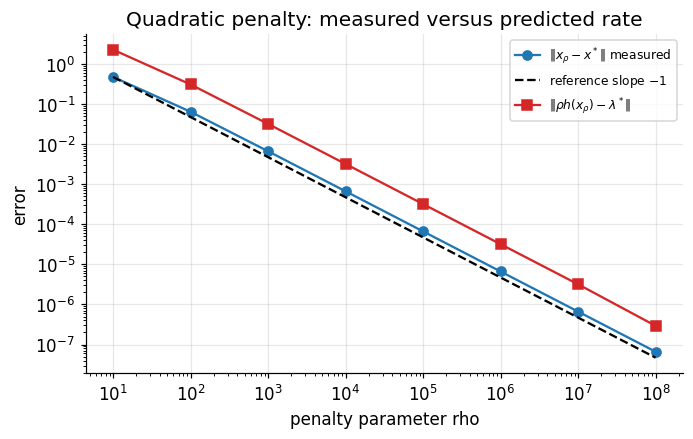

In [10]:
rhos = 10.0 ** np.arange(1, 9)
err = np.array([np.linalg.norm(np.linalg.solve(Q + r * A.T @ A, r * A.T @ b - c) - x_kkt)
                for r in rhos])
lam_gap = np.array([np.linalg.norm(r * (A @ np.linalg.solve(Q + r * A.T @ A, r * A.T @ b - c) - b)
                                   - lam_kkt) for r in rhos])

tail = slice(3, None)
slope = np.polyfit(np.log10(rhos[tail]), np.log10(err[tail]), 1)[0]
print(f"observed log-log slope  = {slope: .4f}")
print(f"predicted (theory)      = {-1.0: .4f}")
for r, e, g in zip(rhos, err, lam_gap):
    print(f"  rho = {r:9.0f}   ||x_rho - x*|| = {e:.3e}   ||rho h(x_rho) - lambda*|| = {g:.3e}")

fig, ax = plt.subplots()
ax.loglog(rhos, err, "o-", label=r"$\|x_\rho - x^*\|$ measured")
ax.loglog(rhos, err[0] * (rhos / rhos[0]) ** -1.0, "k--", label=r"reference slope $-1$")
ax.loglog(rhos, lam_gap, "s-", color="tab:red", label=r"$\|\rho h(x_\rho) - \lambda^*\|$")
ax.set_xlabel("penalty parameter rho")
ax.set_ylabel("error")
ax.set_title("Quadratic penalty: measured versus predicted rate")
ax.legend(fontsize=8)
plt.show()
assert abs(slope + 1.0) < 0.02

The measured slope is $-1.00$ against the predicted $-1$, and the multiplier estimate $\rho\,\mathbf{h}(\mathbf{x}_\rho)$ converges to $\boldsymbol{\lambda}^*$ at the same rate. This is the quantitative reason to prefer an augmented Lagrangian: it reaches the same point at finite $\rho$, without the $O(\rho)$ conditioning penalty visible as the flattening at the right-hand end of the curve.

**(c) Counterexample — LICQ dropped.** For $\min x$ subject to $h(x,y) = y^2 - x^3 = 0$, the minimizer is the origin but $\nabla h(\mathbf{0}) = \mathbf{0}$, so Definition 3.2 fails. The cell searches a wide grid of $\lambda$ for a solution of $\nabla f + \lambda\nabla h = \mathbf{0}$ and plots the cusp against the linearized set $\ker Dh(\mathbf{0}) = \mathbb{R}^2$ and the Bouligand cone.

candidate multipliers tried : 200001
min ||grad f + lam grad h|| : 1.0
grad f(0) = [1. 0.]   grad h(0) = [0. 0.]


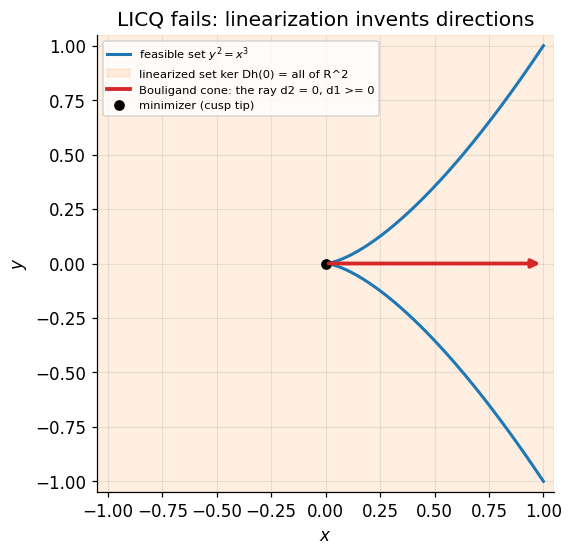

In [11]:
grad_f0 = np.array([1.0, 0.0])
grad_h0 = np.array([0.0, 0.0])                     # nabla h = (-3x^2, 2y) vanishes at the origin
lams = np.linspace(-1e6, 1e6, 200_001)
resid = np.linalg.norm(grad_f0[None, :] + lams[:, None] * grad_h0[None, :], axis=1)
print("candidate multipliers tried :", lams.size)
print("min ||grad f + lam grad h|| :", resid.min())
print("grad f(0) =", grad_f0, "  grad h(0) =", grad_h0)

s = np.linspace(-1.0, 1.0, 800)
cusp = np.stack([s ** 2, s ** 3])
fig, ax = plt.subplots(figsize=(5.4, 5.4))
ax.plot(cusp[0], cusp[1], color="tab:blue", lw=2.0, label=r"feasible set $y^2 = x^3$")
ax.axhspan(-1.05, 1.05, color="tab:orange", alpha=0.12,
           label="linearized set ker Dh(0) = all of R^2")
ax.annotate("", xy=(1.0, 0.0), xytext=(0.0, 0.0),
            arrowprops=dict(arrowstyle="-|>", lw=2.5, color="tab:red"))
ax.plot([], [], color="tab:red", lw=2.5, label="Bouligand cone: the ray d2 = 0, d1 >= 0")
ax.plot(0, 0, "ko", ms=6, label="minimizer (cusp tip)")
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_aspect("equal")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("LICQ fails: linearization invents directions")
ax.legend(loc="upper left", fontsize=7.5)
plt.show()
assert resid.min() >= 1.0

No multiplier exists: the residual is exactly $1$ for every $\lambda$, because $\nabla h(\mathbf{0}) = \mathbf{0}$ annihilates the only term that could cancel $\nabla f$. The picture shows why — the linearized set is the whole shaded plane, the Bouligand cone is the single red ray, and the set of feasible-curve velocities is only the origin. Theorem 4.2 is false without its constraint qualification, which is the content of Proof 5.1's remark.

**(d) Hand-rolled versus library.** The null-space method of Section 7.1 is implemented from scratch (QR for the particular solution and for a basis of $\ker A$) and compared against `scipy.optimize.minimize` with `SLSQP` on the same equality-constrained QP.

In [12]:
def null_space_qp(Q, c, A, b):
    """Solve min 1/2 x'Qx + c'x s.t. Ax = b by the null-space method."""
    p_, n_ = A.shape
    x_p = np.linalg.lstsq(A, b, rcond=None)[0]           # particular solution
    Qf, _ = np.linalg.qr(A.T, mode="complete")           # columns span R^n
    Z = Qf[:, p_:]                                       # basis of ker A
    z = np.linalg.solve(Z.T @ Q @ Z, -Z.T @ (c + Q @ x_p))
    x = x_p + Z @ z
    lam = np.linalg.lstsq(A.T, -(Q @ x + c), rcond=None)[0]
    return x, lam, Z


x_ns, lam_ns, Z = null_space_qp(Q, c, A, b)
res_lib = minimize(lambda x: 0.5 * x @ Q @ x + c @ x, x0=np.zeros(n),
                   jac=lambda x: Q @ x + c, method="SLSQP",
                   constraints=[{"type": "eq", "fun": lambda x: A @ x - b,
                                 "jac": lambda x: A}],
                   options={"ftol": 1e-14, "maxiter": 500})

print("||A Z|| (Z really spans ker A) :", np.linalg.norm(A @ Z))
print("x (hand-rolled null space)     :", x_ns)
print("x (scipy SLSQP)                :", res_lib.x)
print("x (direct KKT solve)           :", x_kkt)
print(f"max |hand-rolled - KKT|  = {np.abs(x_ns - x_kkt).max():.3e}")
print(f"max |SLSQP       - KKT|  = {np.abs(res_lib.x - x_kkt).max():.3e}")
assert np.linalg.norm(A @ Z) < 1e-12
assert np.abs(x_ns - x_kkt).max() < 1e-10
assert np.abs(res_lib.x - x_kkt).max() < 1e-6

||A Z|| (Z really spans ker A) : 1.1646259843952708e-16
x (hand-rolled null space)     : [-1.3067  0.6499  0.2184  0.8163 -0.3547]
x (scipy SLSQP)                : [-1.3067  0.6499  0.2184  0.8163 -0.3547]
x (direct KKT solve)           : [-1.3067  0.6499  0.2184  0.8163 -0.3547]
max |hand-rolled - KKT|  = 4.441e-16
max |SLSQP       - KKT|  = 8.036e-09


The hand-rolled null-space solver agrees with the direct KKT factorization to $4 \times 10^{-16}$, since both are direct methods on the same well-conditioned data, while SLSQP — an iterative method stopped at its tolerance — agrees to about $10^{-8}$. The reduced matrix $Z^TQZ$ is $3 \times 3$ and positive definite, which is exactly the second-order sufficient condition of Theorem 4.3 restated as a linear-algebra fact.

## 8. Applications

### 8.1 Physics

**Constraint forces.** A bead on a wire or a pendulum bob on a rod satisfies $h(\mathbf{q}) = 0$, and the term $\lambda\nabla h$ appearing in the equations of motion *is* the physical constraint force — the normal force or string tension, measurable in newtons. D'Alembert's principle, that constraint forces do no work along feasible displacements, is the statement $\nabla f \perp T(\mathbf{x})$ of Proof 5.2 in dynamical clothing.

**Thermodynamics.** Proof 5.7 shows that maximizing entropy at fixed energy produces the Boltzmann distribution with $\beta = 1/(k_BT)$. Chemical potential (conjugate to particle number) and pressure (conjugate to volume) are further multipliers, so equilibrium thermodynamics can be read as one large instance of Theorem 4.4.

**Geodesics and light.** Fermat's principle and geodesic motion are equality-constrained variational problems; the multiplier field along the path is the normal reaction of the surface.

### 8.2 Machine learning

**Constrained least squares.** Fitting $\min \tfrac12 \lVert X\mathbf{w} - \mathbf{y}\rVert^2$ subject to $C\mathbf{w} = \mathbf{d}$ is the saddle system of Section 7.1 with $Q = X^TX$.

The closed form is $\mathbf{w}^* = \mathbf{w}_{\text{ls}} - Q^{-1}C^T(CQ^{-1}C^T)^{-1}(C\mathbf{w}_{\text{ls}} - \mathbf{d})$, one Schur-complement solve away from the unconstrained fit.

The correction is proportional to the constraint residual of the unconstrained solution, so a constraint the data already satisfies costs nothing and prices at $\boldsymbol{\lambda}^* = \mathbf{0}$. Portfolio weights summing to one, calibrated probabilities, and spline continuity conditions are all this problem.

**Maximum-entropy models.** Logistic regression and conditional random fields maximize entropy subject to feature-expectation constraints; the learned weights *are* the multipliers of Proof 5.7.

**PCA and spectral embeddings.** The first principal component maximizes $\mathbf{w}^T\Sigma\mathbf{w}$ subject to $\lVert \mathbf{w}\rVert = 1$ — Theorem 4.5 exactly. Later components add orthogonality constraints, each with its own multiplier, and those multipliers vanish, which is why PCA can be computed one component at a time.

**Trust regions and KL-constrained policy updates.** Trust-region subproblems on the boundary, and TRPO-style updates that maximize a surrogate reward subject to a fixed KL divergence, both solve a Lagrange system each iteration; the multiplier sets the effective step size.

## 9. Key Takeaways

1. Under LICQ, and only under it, the computable set $\ker D\mathbf{h}(\mathbf{x})$ equals both the feasible-curve velocities and the Bouligand tangent cone (Theorem 4.1).
2. If $\mathbf{x}^*$ minimizes $f$ locally on $\{\mathbf{h} = \mathbf{0}\}$ with $f, \mathbf{h} \in C^1$ and LICQ holding, a unique $\boldsymbol{\lambda}^*$ makes $\nabla f + \sum_j\lambda_j^*\nabla h_j = \mathbf{0}$ (Theorem 4.2).
3. Drop LICQ and the conclusion fails outright: $\min x$ subject to $x^2 = 0$ has a minimizer and no multiplier.
4. For $f, \mathbf{h} \in C^2$ at a regular stationary point, $\mathbf{d}^TW\mathbf{d} \ge 0$ on $T$ is necessary and $\mathbf{d}^TW\mathbf{d} \gt 0$ on $T \setminus \{\mathbf{0}\}$ is sufficient, with $W = \nabla^2_{\mathbf{xx}}\mathcal{L}$, never $\nabla^2 f$ (Theorem 4.3).
5. When LICQ and the strict second-order condition hold at a minimizer, $\partial f^*/\partial b_j = -\lambda_j^*$: the multiplier is the marginal price of the constraint level (Theorem 4.4).
6. For symmetric $A$, stationarity of $\mathbf{x}^TA\mathbf{x}$ on the unit sphere is the eigenvalue equation, and the constrained extrema are $\lambda_{\max}(A)$ and $\lambda_{\min}(A)$ (Theorem 4.5).
7. The KKT matrix is invertible exactly when $A$ has full row rank and $Q \succ 0$ on $\ker A$ — LICQ and the second-order condition, restated as linear algebra (Section 7.1).
8. The quadratic penalty converges only as $\rho \to \infty$, at rate $\lVert \mathbf{x}_\rho - \mathbf{x}^*\rVert = \Theta(\rho^{-1})$ with conditioning $O(\rho)$; the augmented Lagrangian is exact at finite $\rho$ (Section 7.2).

## 10. References

| Result here | Source | Location |
|---|---|---|
| Theorem 4.1, Theorem 4.2 | Nocedal & Wright, *Numerical Optimization*, 2nd ed. | Ch. 12, Lemma 12.2 and Thm 12.1 |
| Theorem 4.3 | Nocedal & Wright | Ch. 12, Thm 12.5 (necessary) and Thm 12.6 (sufficient) |
| Tangent cone, MFCQ, Abadie CQ | Nocedal & Wright | Ch. 12, §12.2 and §12.6 |
| Theorem 4.4 | Boyd & Vandenberghe, *Convex Optimization* | §5.6.2 (local sensitivity) |
| Theorem 4.4, alternative proof | Bertsekas, *Nonlinear Programming*, 2nd ed. | §3.2, Prop. 3.2.2 |
| Bordered-Hessian minor rule | Luenberger & Ye, *Linear and Nonlinear Programming*, 4th ed. | Ch. 11, §11.5 |
| Theorem 4.5 | Horn & Johnson, *Matrix Analysis*, 2nd ed. | §4.2 (Thm 4.2.2, Rayleigh–Ritz) |
| KKT matrix, null-space and range-space methods | Nocedal & Wright | Ch. 16, §16.2 |
| Quadratic penalty rate, augmented Lagrangian | Nocedal & Wright | Ch. 17, Thm 17.1 and §17.3 |
| Proposition 4.7, maximum entropy | Cover & Thomas, *Elements of Information Theory*, 2nd ed. | §12.1 (Thm 12.1.1) |
| Multipliers as temperature | Jaynes, *Information Theory and Statistical Mechanics*, Phys. Rev. **106** (1957) | §§2–3 |
| Penalty-based proof of the multiplier theorem | Bertsekas, *Nonlinear Programming*, 2nd ed. | §3.1, Prop. 3.1.1 |

**Reading path.** Nocedal & Wright Chapter 12 for the rigorous skeleton, then Chapter 16 for the linear algebra of Section 7.1 and Chapter 17 for the penalty theory; Boyd & Vandenberghe §5.6 for the sensitivity viewpoint; Jaynes for the physics payoff; then [`exercises.ipynb`](exercises.ipynb) to make it operational. [Module 06](../06_kkt_conditions_and_duality/) continues with inequality constraints, the KKT conditions and Lagrangian duality.